Using device: cuda
Epoch 50, Loss: -1.805915117263794
Epoch 100, Loss: -1.5822831392288208
Epoch 150, Loss: -1.121973991394043
Epoch 200, Loss: -3.049884557723999
Epoch 250, Loss: -3.0699217319488525
Epoch 300, Loss: -3.4529166221618652
Epoch 350, Loss: -2.608041763305664
Epoch 400, Loss: -1.6606581211090088
Epoch 450, Loss: -3.010070323944092
Epoch 500, Loss: -2.8093576431274414
final best loss: -3.97751522064209


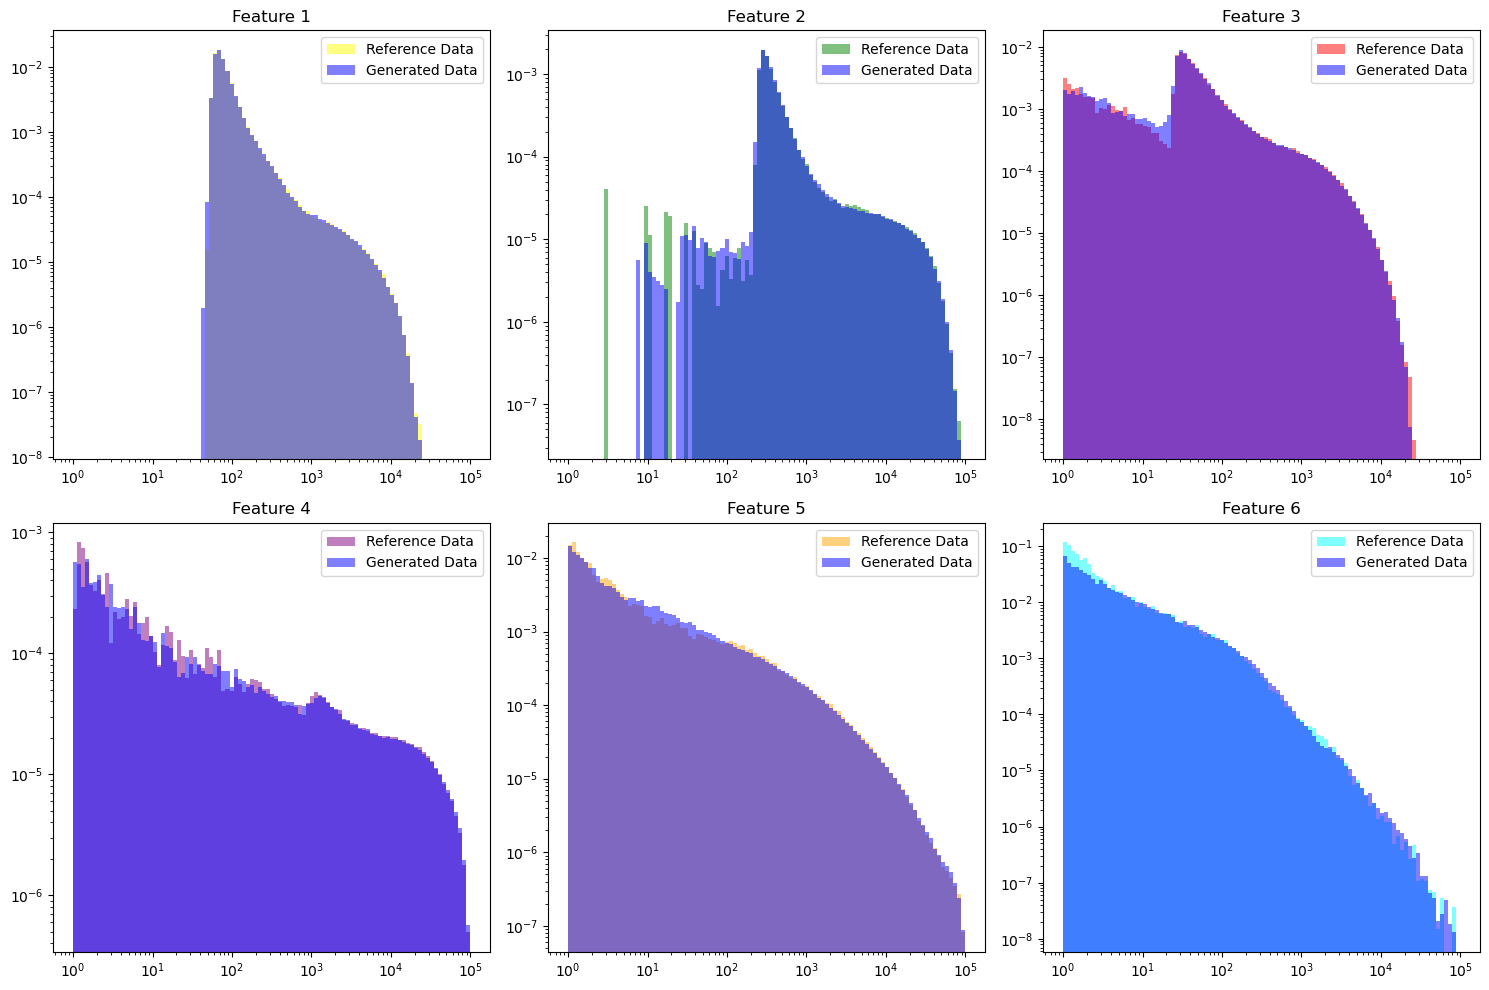

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
Final real data shape: (70000, 7)
Final gen shape: (70000, 7)
Epoch number 0/24
----------
train Loss: 0.693255046 Acc: 0.509187500
val Loss: 0.692798938 Acc: 0.512178571
Epoch number 1/24
----------
train Loss: 0.692628947 Acc: 0.513660714
val Loss: 0.691957255 Acc: 0.525535714
Epoch number 2/24
----------
train Loss: 0.692417761 Acc: 0.516008929
val Loss: 0.691960971 Acc: 0.529142857
Epoch number 3/24
----------
train Loss: 0.692108185 Acc: 0.519669643
val Loss: 0.692139199 Acc: 0.519321429
Epoch number 4/24
----------
train Loss: 0.692171346 Acc: 0.518267857
val Loss: 0.691781290 Acc: 0.521785714
Epoch number 5/24
----------
train Loss: 0.691933680 Acc: 0.520035714
val Loss: 0.691502233 Acc: 0.523214286
Epoch number 6/24
----------
train Loss: 0.691758254 Acc: 0.519482143
val Loss: 0.691805219 Acc: 0.524821429
Epoch number 7/24
----------
train Loss: 0.691814859 Acc: 0.520669643
val Loss: 0.691780180 Acc: 0.523214286
Epoch number 8/24


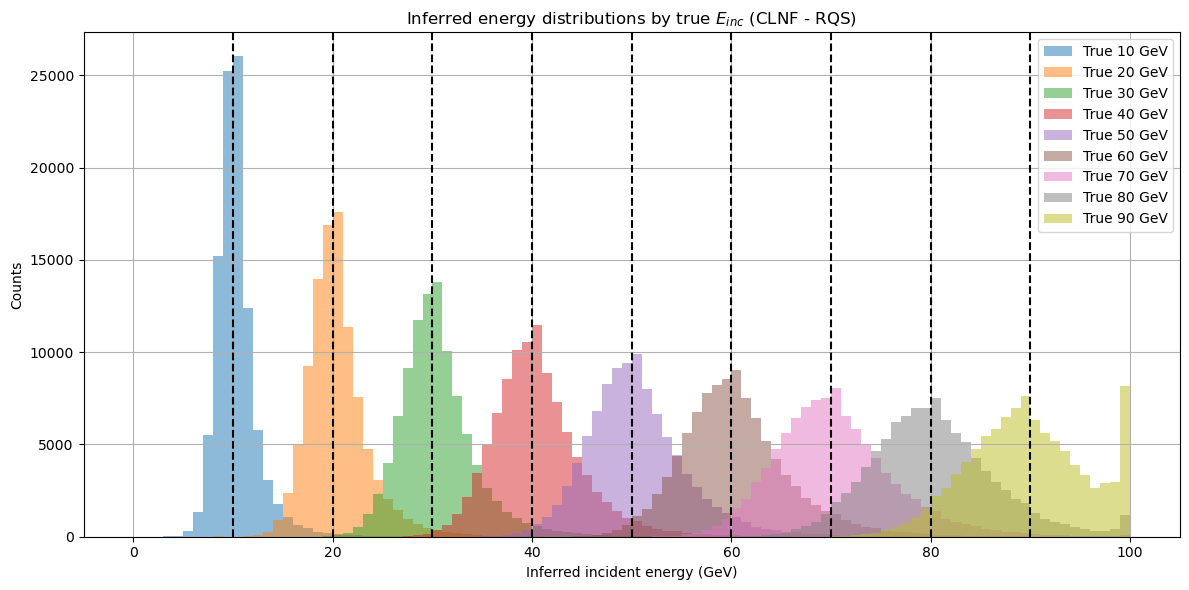

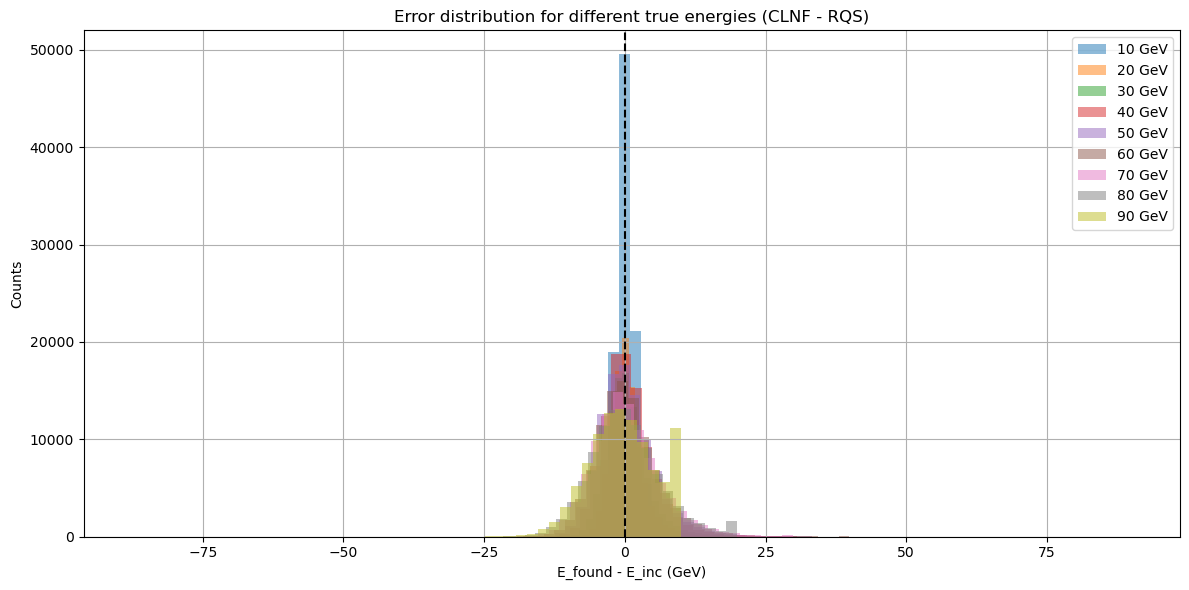

Total time taken: 6h 59m 33.17s


In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score
from nflows.flows.base import Flow
from nflows.distributions.normal import StandardNormal
from nflows.transforms.base import CompositeTransform
from nflows.transforms.coupling import PiecewiseRationalQuadraticCouplingTransform
from nflows.transforms.permutations import ReversePermutation
import time
import torch.nn as nn
import torch.optim as optim
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
import torch.nn.functional as F
import copy
import os

start_time = time.time()

results_folder = "CLNF_RQS_results"
os.makedirs(results_folder, exist_ok=True)
results_txt_path = os.path.join(results_folder, "clnf_rqs_results.txt")
results_log = []

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

ALPHA = 1e-6

def format_hms(seconds):
    hours, rem = divmod(seconds, 3600)
    minutes, seconds = divmod(rem, 60)
    return f"{int(hours)}h {int(minutes)}m {seconds:.2f}s"

def logit(x):
    return torch.log(x / (1.0 - x))

def logit_trafo(x):
    local_x = torch.clamp(ALPHA + (1. - 2. * ALPHA) * x, min=1e-6, max=1 - 1e-6)
    return logit(local_x)

def inverse_logit(x):
    return (torch.sigmoid(x) - ALPHA) / (1. - 2.*ALPHA)

def logit_np(x):
    return np.log(x / (1.0 - x))

def logit_trafo_np(x):
    local_x = np.clip(ALPHA + (1. - 2. * ALPHA) * x, 1e-6, 1 - 1e-6)
    return logit_np(local_x)

def logit_reg(x):
    return torch.log(x / (1.0 - x))

def logit_trafo_reg(x):
    local_x = torch.clamp(ALPHA + (1. - 2. * ALPHA) * x, min=1e-6, max=1 - 1e-6)
    return logit_reg(local_x)

def inverse_logit_reg(x):
    return (torch.sigmoid(x) - ALPHA) / (1. - 2.*ALPHA)

def compute_summary_metrics(errors, true_energy=None):
    if len(errors) == 0:
        return {
            "N": 0,
            "Bias": np.nan,
            "MAE": np.nan,
            "RMSE": np.nan,
            "Std": np.nan,
            "Median": np.nan,
            "Width68": np.nan,
            "RelMAE": np.nan,
            "RelRMSE": np.nan
        }

    bias = np.mean(errors)
    mae = np.mean(np.abs(errors))
    rmse = np.sqrt(np.mean(errors**2))
    std = np.std(errors)
    median = np.median(errors)
    q16, q84 = np.percentile(errors, [16, 84])
    width68 = q84 - q16

    if true_energy is None:
        rel_mae = np.nan
        rel_rmse = np.nan
    else:
        rel_errors = errors / true_energy
        rel_mae = 100.0 * np.mean(np.abs(rel_errors))
        rel_rmse = 100.0 * np.sqrt(np.mean(rel_errors**2))

    return {
        "N": len(errors),
        "Bias": bias,
        "MAE": mae,
        "RMSE": rmse,
        "Std": std,
        "Median": median,
        "Width68": width68,
        "RelMAE": rel_mae,
        "RelRMSE": rel_rmse
    }

path_to_data = '/groups/hephy/mlearning/CaloRegression/training/'
my_file = h5py.File(path_to_data + 'train_piplus.hdf5', 'r')
energy = my_file['energy'][:]
layers = [my_file[f'layer_{i}'][:] for i in range(6)]
E_layers = np.array([layer.sum(axis=(1, 2)) for layer in layers]).T

data = np.hstack((energy.reshape(-1, 1), E_layers))
data[np.isinf(data)] = np.nan
valid_mask = ~np.isnan(data).any(axis=1)
data = data[valid_mask]

data_tensor = torch.tensor(data, dtype=torch.float32).to(device)

data_max = data_tensor.max(dim=0).values
data_tensor = data_tensor / data_max
data_tensor = logit_trafo(data_tensor)

mask = ~torch.isnan(data_tensor).any(dim=1) & ~torch.isinf(data_tensor).any(dim=1)
data_tensor = data_tensor[mask]
data = data[mask.cpu().numpy()]

data_mean = data_tensor.mean(dim=0)
data_std = data_tensor.std(dim=0)
data_tensor = (data_tensor - data_mean) / data_std

data_mean_reg = data_mean
data_std_reg = data_std
data_max_reg = data_max

context_feature = data_tensor[:, 0].unsqueeze(1)
input_features = data_tensor[:, 1:]

num_layers = 10
num_features = input_features.shape[1]
base_distribution = StandardNormal(shape=[num_features])

transforms = []

masks = [torch.arange(num_features) % 2 for _ in range(num_layers)]
masks = [mask if i % 2 == 0 else 1 - mask for i, mask in enumerate(masks)]

class CouplingMLP(nn.Module):
    def __init__(self, in_features, out_features, context_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features + context_features, 64), nn.ReLU(),
            nn.Linear(64, 64), nn.ReLU(),
            nn.Linear(64, out_features)
        )
        self.hidden_features = 64

    def forward(self, identity_split, context):
        inputs = torch.cat([identity_split, context], dim=-1)
        return self.net(inputs)

for i in range(num_layers):
    transforms.append(PiecewiseRationalQuadraticCouplingTransform(
        mask=masks[i],
        transform_net_create_fn=lambda in_features, out_features: CouplingMLP(in_features, out_features, context_features=1),
        num_bins=10,
        tails="linear",
        tail_bound=15.0
    ))

transform = CompositeTransform(transforms)
flow = Flow(transform, base_distribution).to(device)

optimizer = torch.optim.Adam(flow.parameters(), lr=1e-4)
num_epochs = 500
batch_size = 256
best_loss = float('inf')

generative_start_time = time.time()

for epoch in range(num_epochs):
    idx = torch.randperm(len(data_tensor), device=data_tensor.device)
    data_tensor = data_tensor[idx]
    context_feature = data_tensor[:, 0].unsqueeze(1)
    input_features = data_tensor[:, 1:]

    for i in range(0, len(input_features), batch_size):
        batch_inputs = input_features[i:i + batch_size]
        batch_context = context_feature[i:i + batch_size]
        optimizer.zero_grad()
        loss = -flow.log_prob(inputs=batch_inputs, context=batch_context).mean()
        if not torch.isnan(loss) and not torch.isinf(loss):
            loss.backward()
            optimizer.step()
            best_loss = min(best_loss, loss.item())
        else:
            print("skipping")

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch + 1}, Loss: {loss.item()}")

print(f"final best loss: {best_loss}")

n_samples = 200000
batch_size = 1000
all_samples = []

Einc_gen_phys = torch.rand((n_samples, 1), device=device) * 99 + 1
Einc_gen = Einc_gen_phys / data_max[0]
Einc_gen = logit_trafo(Einc_gen)
Einc_gen = (Einc_gen - data_mean[0]) / data_std[0]

with torch.no_grad():
    for i in range(0, n_samples, batch_size):
        batch_context = Einc_gen[i:i + batch_size]
        samples_batch = flow.sample(1, context=batch_context).detach().cpu()
        all_samples.append(samples_batch)

samples = torch.cat(all_samples, dim=0)
samples = samples * data_std[1:].cpu() + data_mean[1:].cpu()
samples = inverse_logit(samples)
samples = samples * data_max[1:].cpu()
samples = samples.squeeze().numpy()

fig, axs = plt.subplots(2, 3, figsize=(15, 10))
axs = axs.flatten()
colors = ['yellow', 'green', 'red', 'purple', 'orange', 'cyan']

for i in range(data.shape[1] - 1):
    bins = np.logspace(0, 5, 100)
    counts, bin_edges, _ = axs[i].hist(
        data[:, i + 1], bins=bins, alpha=0.5, label="Reference Data", color=colors[i % len(colors)], density=True, log=True
    )
    axs[i].hist(samples[:, i], bins=bin_edges, alpha=0.5, label="Generated Data", color='blue', density=True, log=True)
    axs[i].set_xscale('log')
    axs[i].legend()
    axs[i].set_title(f"Feature {i + 1}")

for j in range(len(axs)):
    if j >= data.shape[1] - 1:
        axs[j].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(results_folder, "layer_energy_histograms.png"), dpi=300, bbox_inches='tight')
plt.show()

generative_end_time = time.time()
generative_elapsed = generative_end_time - generative_start_time

real_data = data.copy()
generated_data = np.hstack((Einc_gen_phys.cpu().numpy(), samples))

print(type(real_data))
print(type(generated_data))

combined_phys = np.vstack((real_data, generated_data))

data_max_clf = combined_phys.max(axis=0)

real_data = real_data / data_max_clf
generated_data = generated_data / data_max_clf

real_data = logit_trafo_np(real_data)
generated_data = logit_trafo_np(generated_data)

combined_transformed = np.vstack((real_data, generated_data))
data_mean_clf = combined_transformed.mean(axis=0)
data_std_clf = combined_transformed.std(axis=0)

real_data = (real_data - data_mean_clf) / data_std_clf
generated_data = (generated_data - data_mean_clf) / data_std_clf

smallest_size = min(len(real_data), len(generated_data))

real_indices = np.random.choice(len(real_data), smallest_size, replace=False)
generated_indices = np.random.choice(len(generated_data), smallest_size, replace=False)

real_data = real_data[real_indices]
generated_data = generated_data[generated_indices]

print(f"Final real data shape: {real_data.shape}")
print(f"Final gen shape: {generated_data.shape}")

real_labels = np.ones(len(real_data))
maf_labels = np.zeros(len(generated_data))

combined_data = np.vstack((real_data, generated_data))
combined_labels = np.hstack((real_labels, maf_labels))

X_train, X_test, y_train, y_test = train_test_split(combined_data, combined_labels, test_size=0.2, random_state=42, stratify=combined_labels)

class SimpleNN(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, 1)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = F.leaky_relu(self.fc1(x), negative_slope=0.01)
        x = self.dropout(x)
        x = F.leaky_relu(self.fc2(x), negative_slope=0.01)
        x = self.dropout(x)
        x = torch.sigmoid(self.fc3(x))
        return x

def train_model(model, criterion, optimizer, dataloaders, num_epochs=25):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print('Epoch number {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device).float().unsqueeze(1)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    preds = torch.round(outputs)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)

            print('{} Loss: {:.9f} Acc: {:.9f}'.format(
                phase, epoch_loss, epoch_acc))

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

    print('highest validation accuracy: {:9f}'.format(best_acc))
    model.load_state_dict(best_model_wts)
    return model

def evaluate_model(model, dataloaders):
    model.eval()
    all_preds = []
    all_labels = []
    all_preds_auc = []

    for inputs, labels in dataloaders['val']:
        inputs = inputs.to(device)
        labels = labels.to(device).float().unsqueeze(1)

        with torch.no_grad():
            outputs = model(inputs)
            preds = torch.round(outputs)
            preds_auc = outputs
            all_preds_auc.append(preds_auc.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_preds_auc = np.concatenate(all_preds_auc)
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    acc = accuracy_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_preds_auc)
    print('Accuracy: {:.9f}, AUC (area under roc curve): {:.9f}'.format(acc, auc))
    return acc, auc

train_dataset = torch.utils.data.TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32))
test_dataset = torch.utils.data.TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.float32))

dataloaders = {
    'train': torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True),
    'val': torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)
}

input_dim = combined_data.shape[1]
hidden_dim = 64
model = SimpleNN(input_dim, hidden_dim)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

classifier_start_time = time.time()
model = train_model(model, criterion, optimizer, dataloaders, num_epochs=25)
final_acc, final_auc = evaluate_model(model, dataloaders)
classifier_end_time = time.time()
classifier_elapsed = classifier_end_time - classifier_start_time

def load_and_preprocess_test_file(filepath, data_mean_reg, data_std_reg, data_max_reg):
    with h5py.File(filepath, 'r') as f:
        energy = f['energy'][:]
        layers = [f[f'layer_{i}'][:] for i in range(6)]
        E_layers = np.array([layer.sum(axis=(1, 2)) for layer in layers]).T

    data = np.hstack((energy.reshape(-1, 1), E_layers))
    data[np.isinf(data)] = np.nan
    valid_mask = ~np.isnan(data).any(axis=1)
    data = data[valid_mask]

    tensor_data = torch.tensor(data, dtype=torch.float32).to(device)
    tensor_data = tensor_data / data_max_reg
    tensor_data = logit_trafo_reg(tensor_data)
    tensor_data = (tensor_data - data_mean_reg) / data_std_reg

    return tensor_data[:, 1:], data[:, 0]

def infer_incident_energy(flow, layer_tensor, data_mean_reg, data_std_reg, data_max_reg, num_scan_points=1000):
    device = layer_tensor.device
    n_samples = layer_tensor.shape[0]
    Emax_eff = float(data_max_reg[0].item()) * 0.999
    E_candidates = torch.linspace(1, Emax_eff, num_scan_points, device=device).view(-1, 1)

    E_candidates_norm = E_candidates / data_max_reg[0]
    E_candidates_logit = logit_trafo_reg(E_candidates_norm)
    E_candidates_std = (E_candidates_logit - data_mean_reg[0]) / data_std_reg[0]

    E_context = E_candidates_std.view(1, -1, 1).repeat(n_samples, 1, 1)
    inputs = layer_tensor.unsqueeze(1).repeat(1, num_scan_points, 1)

    flat_inputs = inputs.view(-1, inputs.shape[-1])
    flat_context = E_context.view(-1, 1)

    batch_size = 1000
    log_probs_list = []
    with torch.no_grad():
        for i in range(0, flat_inputs.shape[0], batch_size):
            inputs_batch = flat_inputs[i:i + batch_size]
            context_batch = flat_context[i:i + batch_size]
            log_probs_batch = flow.log_prob(inputs_batch, context=context_batch)
            log_probs_list.append(log_probs_batch)

    log_probs = torch.cat(log_probs_list).view(n_samples, num_scan_points)
    max_indices = log_probs.argmax(dim=1)
    inferred_E = E_candidates[max_indices].cpu().numpy()

    return inferred_E

data_mean_reg = data_mean_reg.to(device)
data_std_reg = data_std_reg.to(device)
data_max_reg = data_max_reg.to(device)
flow = flow.to(device)

regression_start_time = time.time()

eval_folder = '/groups/hephy/mlearning/CaloRegression/evaluation'
energy_values = list(range(10, 91, 10))

errors_by_energy = {}
per_energy_rows = []
all_filtered_errors = []
all_filtered_true = []
Emax_eff = float(data_max_reg[0].item()) * 0.999

for E_true in energy_values:
    file_path = os.path.join(eval_folder, f'piplus_{E_true}GeV.hdf5')

    layer_tensor, true_energy_array = load_and_preprocess_test_file(file_path, data_mean_reg, data_std_reg, data_max_reg)
    inferred = infer_incident_energy(flow, layer_tensor, data_mean_reg, data_std_reg, data_max_reg)

    inferred = np.asarray(inferred).reshape(-1)
    true_energy_array = np.asarray(true_energy_array).reshape(-1)

    error = inferred - true_energy_array
    errors_by_energy[E_true] = error

    edge_mask = (np.isclose(inferred, 1.0)) | (np.isclose(inferred, Emax_eff))
    satfrac = 100.0 * np.mean(edge_mask)
    filtered_error = error[~edge_mask]
    filtered_true = true_energy_array[~edge_mask]

    metrics = compute_summary_metrics(filtered_error, filtered_true)

    per_energy_rows.append({
        "E_true": E_true,
        "N": metrics["N"],
        "Bias": metrics["Bias"],
        "MAE": metrics["MAE"],
        "RMSE": metrics["RMSE"],
        "Std": metrics["Std"],
        "Median": metrics["Median"],
        "Width68": metrics["Width68"],
        "SatFrac": satfrac
    })

    all_filtered_errors.append(filtered_error)
    all_filtered_true.append(filtered_true)

    mean_error = np.mean(error)
    std_error = np.std(error)
    print(f"E_inc={E_true} GeV: mean error = {mean_error:.2f}, std = {std_error:.2f}")

    bins = 100
    counts, bin_edges = np.histogram(inferred, bins=bins, range=(1, float(data_max_reg[0].item())))

    bin_idx = np.digitize(E_true, bin_edges) - 1
    if bin_idx < 0:
        bin_idx = 0
    if bin_idx >= len(counts):
        bin_idx = len(counts) - 1

    true_bin_count = counts[bin_idx]
    total_counts = counts.sum()
    ratio_true_bin = true_bin_count / total_counts if total_counts > 0 else 0

    print(f"  Bin count of true energy ({E_true} GeV): {true_bin_count} ({ratio_true_bin:.2%} of all results)")

    max_count = counts.max()
    half_max = max_count / 2

    above_half_max = np.where(counts >= half_max)[0]
    if len(above_half_max) > 0:
        fwhm_start = bin_edges[above_half_max[0]]
        fwhm_end = bin_edges[above_half_max[-1] + 1]
        fwhm = fwhm_end - fwhm_start
    else:
        fwhm = 0

    print(f"  Full width at half maximum (FWHM): {fwhm:.2f} GeV")

plt.figure(figsize=(12, 6))

for E_true, error in errors_by_energy.items():
    inferred = error + E_true
    plt.hist(inferred, bins=100, range=(0, 100), alpha=0.5, label=f'True {E_true} GeV')
    plt.axvline(E_true, color='black', linestyle='--')

plt.legend(loc='best')
plt.xlabel("Inferred incident energy (GeV)")
plt.ylabel("Counts")
plt.title("Inferred energy distributions by true $E_{inc}$ (CLNF - RQS)")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(results_folder, "inferred_energy_distributions_by_true_Einc.png"), dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(12, 6))
for E_true, error in errors_by_energy.items():
    plt.hist(error, bins=50, alpha=0.5, label=f'{E_true} GeV')

plt.axvline(0, color='black', linestyle='--')
plt.xlabel("E_found - E_inc (GeV)")
plt.ylabel("Counts")
plt.legend()
plt.title("Error distribution for different true energies (CLNF - RQS)")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(results_folder, "error_distribution_for_different_true_energies.png"), dpi=300, bbox_inches='tight')
plt.show()

regression_end_time = time.time()
regression_elapsed = regression_end_time - regression_start_time

all_filtered_errors = np.concatenate(all_filtered_errors)
all_filtered_true = np.concatenate(all_filtered_true)
global_metrics = compute_summary_metrics(all_filtered_errors, all_filtered_true)

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Total time taken: {format_hms(elapsed_time)}")

results_log.append("CLNF - RQS results")
results_log.append("====================")
results_log.append("")
results_log.append(f"Final Accuracy: {final_acc:.6f}")
results_log.append(f"Final AUC: {final_auc:.6f}")
results_log.append("")
results_log.append("Timing")
results_log.append("------")
results_log.append(f"1. Generative part without classifier: {format_hms(generative_elapsed)}")
results_log.append(f"2. Classifier: {format_hms(classifier_elapsed)}")
results_log.append(f"3. Regression: {format_hms(regression_elapsed)}")
results_log.append(f"Total time taken: {format_hms(elapsed_time)}")
results_log.append("")
results_log.append("Per-energy regression summary (edge-saturation filtered)")
results_log.append("-------------------------------------------------------")
results_log.append(
    f"{'E_true':>10} {'N':>8} {'Bias':>12} {'MAE':>10} {'RMSE':>10} {'Std':>10} {'Median':>12} {'68% width':>14} {'Sat.frac':>10}"
)

for row in per_energy_rows:
    results_log.append(
        f"{row['E_true']:10d} "
        f"{row['N']:8d} "
        f"{row['Bias']:12.3f} "
        f"{row['MAE']:10.3f} "
        f"{row['RMSE']:10.3f} "
        f"{row['Std']:10.3f} "
        f"{row['Median']:12.3f} "
        f"{row['Width68']:14.3f} "
        f"{row['SatFrac']:9.2f}%"
    )

results_log.append("")
results_log.append("Global regression summary (all energies pooled)")
results_log.append("----------------------------------------------")
results_log.append(f"Total N: {global_metrics['N']}")
results_log.append(f"Bias  [GeV]: {global_metrics['Bias']:.3f}")
results_log.append(f"MAE   [GeV]: {global_metrics['MAE']:.3f}")
results_log.append(f"RMSE  [GeV]: {global_metrics['RMSE']:.3f}")
results_log.append(f"Std   [GeV]: {global_metrics['Std']:.3f}")
results_log.append(f"68% width [GeV]: {global_metrics['Width68']:.3f}")
results_log.append(f"Relative MAE  [%]: {global_metrics['RelMAE']:.3f}")
results_log.append(f"Relative RMSE [%]: {global_metrics['RelRMSE']:.3f}")

with open(results_txt_path, "w") as f:
    for line in results_log:
        f.write(line + "\n")